# Milestone 4 — Continuous batching

Schedule every decode step: evict finished requests, admit waiting ones into free slots.
Compare the same arrival workload under **static waves** vs **continuous** scheduling.

In [1]:
!git clone https://github.com/Jayaprakash-030/tiny-inference-engine.git
%cd tiny-inference-engine
!pip install -q -e .

Cloning into 'tiny-inference-engine'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 82 (delta 40), reused 64 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 153.20 KiB | 1018.00 KiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/tiny-inference-engine
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tiny-inference-engine (pyproject.toml) ... done


In [2]:
from engine import load
from engine.continuous import (
    check_decode_batch_matches_run_one,
    check_run_one_matches_cached,
    measure_pair,
    print_pair,
    sweep_continuous,
)
from engine.results import save

rt = load()
rt.describe()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model : Qwen/Qwen3-0.6B
device: cuda
dtype : torch.float16
layers: 28
gpu   : Tesla T4


### Correctness

In [3]:
assert check_run_one_matches_cached(rt)
assert check_decode_batch_matches_run_one(rt)

continuous run_one matches cached: True
decode_batch matches run_one: True


### One pair (smoke) then sweep + save

In [4]:
s, c = measure_pair(rt, n_requests=16, max_slots=4, max_new_tokens=64)
print_pair(s, c)

--- slots=4  n=16  max_new=64 ---
  static    :    50.42 tok/s  wait   3713.4 ms  lat  5811.02 ms  util  64.5%
  continuous:    73.74 tok/s  wait  1208.07 ms  lat  2739.09 ms  util  84.1%


In [5]:
m4 = sweep_continuous(
    rt,
    slot_sizes=(2, 4, 8, 16),
    n_requests=16,
    max_new_tokens=64,
)
save(m4)

--- slots=2  n=16  max_new=64 ---
  static    :    33.76 tok/s  wait  5875.31 ms  lat  7641.37 ms  util  80.0%
  continuous:    44.57 tok/s  wait  3802.33 ms  lat  5235.14 ms  util  97.8%
--- slots=4  n=16  max_new=64 ---
  static    :    52.29 tok/s  wait  3329.11 ms  lat  5403.04 ms  util  64.5%
  continuous:    74.59 tok/s  wait  1195.29 ms  lat  2693.18 ms  util  84.1%
--- slots=8  n=16  max_new=64 ---
  static    :    74.25 tok/s  wait   1554.8 ms  lat  4255.34 ms  util  56.0%
  continuous:   105.58 tok/s  wait    106.4 ms  lat  1622.69 ms  util  58.9%
--- slots=16  n=16  max_new=64 ---
  static    :     74.7 tok/s  wait   1419.8 ms  lat  4039.38 ms  util  56.4%
  continuous:   104.55 tok/s  wait    60.08 ms  lat  1612.14 ms  util  30.6%
appended 8 results to benchmarks/results.json


### Plot static vs continuous

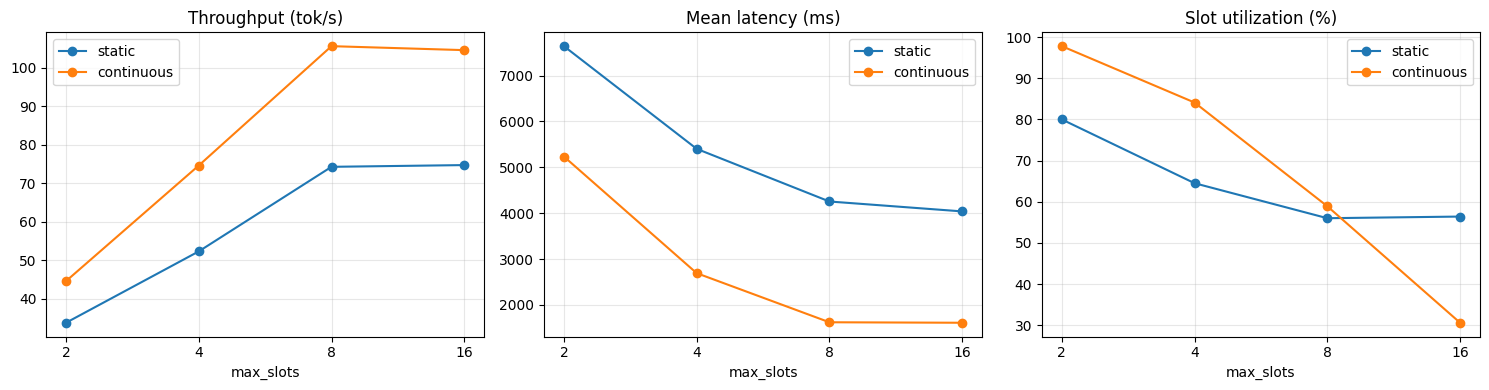

In [6]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("benchmarks/plots").mkdir(parents=True, exist_ok=True)

static = [r for r in m4 if r["mode"] == "static"]
cont = [r for r in m4 if r["mode"] == "continuous"]
slots = [r["max_slots"] for r in static]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in [
    (axes[0], "tokens_per_sec", "Throughput (tok/s)"),
    (axes[1], "mean_latency_ms", "Mean latency (ms)"),
    (axes[2], "slot_util_pct", "Slot utilization (%)"),
]:
    ax.plot(slots, [r[key] for r in static], marker="o", label="static")
    ax.plot(slots, [r[key] for r in cont], marker="o", label="continuous")
    ax.set_title(title)
    ax.set_xlabel("max_slots")
    ax.set_xscale("log", base=2)
    ax.set_xticks(slots)
    ax.set_xticklabels(slots)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("benchmarks/plots/m4_continuous.png", dpi=140)
plt.show()